In [ ]:
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr

In [6]:
with open("../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

train_latents = train["latents"]
train_recon   = train["recon"]
train_re      = train["re"]

val_latents   = val["latents"]
val_recon     = val["recon"]
val_re        = val["re"]

kaon_latents  = kaon["latents"]
kaon_recon    = kaon["recon"]
kaon_re       = kaon["re"]

In [8]:
features = pd.read_pickle('/Volumes/easystore/proton-kaon/features/features.pkl')
index = np.load('/Volumes/easystore/proton-kaon/training/split_p.npz')

train_features = features[features['particle_type'] == 'proton'].iloc[index['train_idx']]
val_features = features[features['particle_type'] == 'proton'].iloc[index['val_idx']]
kaon_features = features[features['particle_type'] == 'kaon']

In [12]:
# ── align latents with features ────────────────────────────────────────
all_proton_features = features[features['particle_type'] == 'proton']
all_kaon_features   = features[features['particle_type'] == 'kaon']

latent_z = np.zeros((len(features), 4))
latent_z[all_proton_features.index[index['train_idx']], :] = train_latents
latent_z[all_proton_features.index[index['val_idx']], :] = val_latents
latent_z[all_kaon_features.index, :] = kaon_latents

features['z0'], features['z1'], features['z2'], features['z3'] = latent_z.T

In [13]:
# ── define feature groups (only available ones) ────────────────────────
calorimetry = ['total_adc', 'mean_adc', 'max_adc',
               'end_vs_start_ratio', 'bragg_peak_ratio', 'bragg_peak_position',
               'profile_skewness', 'profile_kurtosis', 'peak_integral_fraction']
topology = ['height', 'solidity', 'n_pixels']

calorimetry = [f for f in calorimetry if f in features.columns]
topology = [f for f in topology if f in features.columns]
features_of_interest = calorimetry + topology
latents = ['z0', 'z1', 'z2', 'z3']

In [14]:
# ── compute Spearman correlations ──────────────────────────────────────
corr_matrix = np.zeros((len(features_of_interest), len(latents)))

for i, feat in enumerate(features_of_interest):
    for j, lat in enumerate(latents):
        valid = features[[feat, lat]].notna().all(axis=1)
        if valid.sum() > 2:
            rho, _ = spearmanr(features.loc[valid, feat], features.loc[valid, lat])
            corr_matrix[i, j] = rho

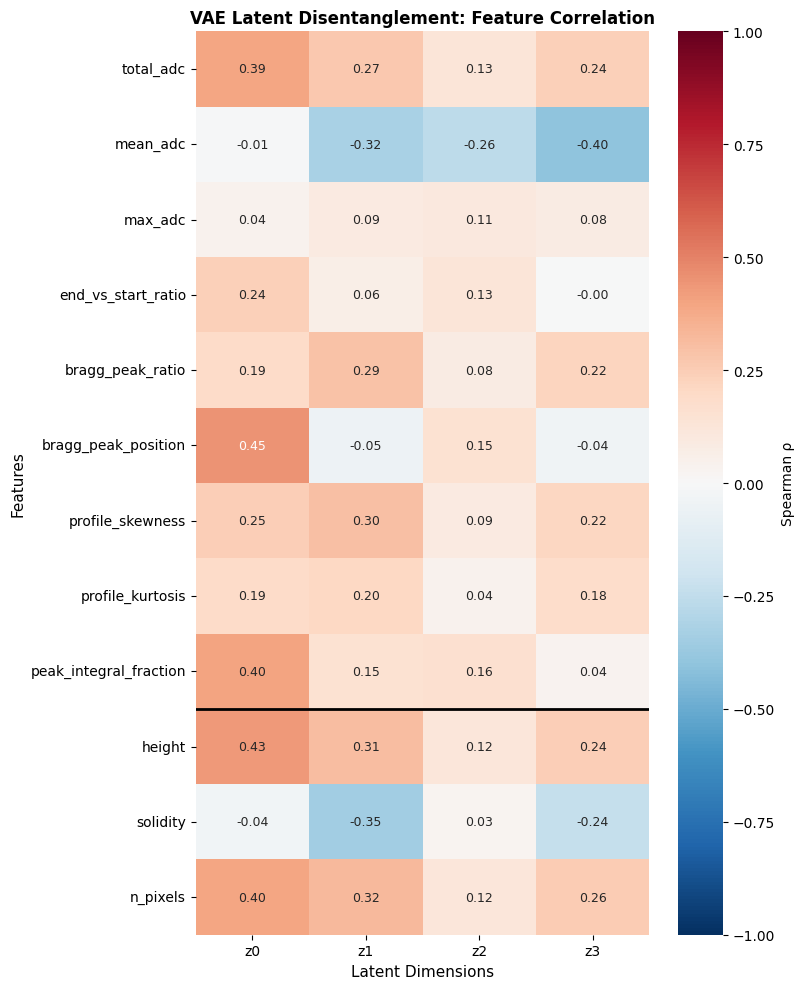

In [17]:
# ── plot heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(corr_matrix,
            xticklabels=latents,
            yticklabels=features_of_interest,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Spearman ρ'},
            annot=True, fmt='.2f', annot_kws={'size': 9},
            ax=ax)

sep_y = len(calorimetry)
ax.axhline(y=sep_y, color='black', linewidth=2)

ax.set_title('VAE Latent Disentanglement: Feature Correlation', fontsize=12, weight='bold')
ax.set_xlabel('Latent Dimensions', fontsize=11)
ax.set_ylabel('Features', fontsize=11)

plt.tight_layout()
plt.savefig('../figs/disentanglement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── summary ────────────────────────────────────────────────────────────
for j, lat in enumerate(latents):
    calo = np.abs(corr_matrix[:len(calorimetry), j])
    topo = np.abs(corr_matrix[len(calorimetry):, j])
    print(f"{lat}: calo mean |ρ|={calo.mean():.3f}, topo mean |ρ|={topo.mean():.3f}, specificity={calo.mean()/topo.mean():.2f}x")

z0: calo mean |ρ|=0.241, topo mean |ρ|=0.289, specificity=0.84x
z1: calo mean |ρ|=0.194, topo mean |ρ|=0.328, specificity=0.59x
z2: calo mean |ρ|=0.129, topo mean |ρ|=0.089, specificity=1.44x
z3: calo mean |ρ|=0.157, topo mean |ρ|=0.246, specificity=0.64x
